
# Part 2 — Quantum Noise Models

Part 1 built and measured *ideal* circuits: every state evolved unitarily, and the only
randomness was the intrinsic randomness of the Born rule. Real hardware is not ideal — qubits
leak energy, dephase, and pick up stray errors from their environment. This notebook builds the
standard vocabulary for that: five single-qubit noise channels, each derived as an explicit set
of **Kraus operators**, implemented, and visualized via their effect on the Bloch sphere.

**Goals**

1. Motivate why physical noise needs a strictly larger mathematical object than a unitary matrix.
2. Derive the Kraus-operator (operator-sum) representation of a quantum channel from first
   principles (system + environment + partial trace) — this is the same `partial_trace` machinery
   from Part 1, doing a different job.
3. Derive, implement, and visualize five channels: bit flip, phase flip, depolarizing, amplitude
   damping, phase damping.
4. Verify every implementation against Qiskit's own built-in noise channels.
5. Show, with one small example, that noise actually degrades something we care about
   (Bell-state fidelity) — a preview of Part 3's full experiment sweep, not a replacement for it.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from qiskit import ClassicalRegister, QuantumCircuit
from qiskit.quantum_info import DensityMatrix, Kraus, SuperOp, Statevector, state_fidelity, purity
from qiskit_aer.noise import (
    pauli_error,
    depolarizing_error,
    amplitude_damping_error,
    phase_damping_error,
)

from src.circuits import bell_state, single_qubit_superposition
from src.simulation import bloch_vector, evolve_density_matrix, sample_counts
from src.noise_models import (
    CHANNEL_KRAUS_BUILDERS,
    bit_flip_kraus,
    phase_flip_kraus,
    depolarizing_kraus,
    amplitude_damping_kraus,
    phase_damping_kraus,
    single_qubit_noise_model,
)
from src.visualization import plot_bloch_vector_decay, plot_purity_vs_parameter, plot_counts_histogram

%matplotlib inline



## Why noise isn't a unitary matrix

Every gate in Part 1 was a unitary $U$ acting on the qubit's own Hilbert space: $|\psi\rangle \to
U|\psi\rangle$, or on a density matrix, $\rho \to U\rho U^\dagger$. This is reversible and
information-preserving by construction ($U^\dagger U = I$).

Physical noise is different in kind, not just degree: a qubit sitting in a lab is never perfectly
isolated. It is weakly coupled to an environment (other modes of the electromagnetic field,
phonons, nearby two-level defects...) that we don't track. Tracing out that environment is
*exactly* the `partial_trace` operation from Part 1's GHZ section — except there we traced out
qubits we control (to study entanglement); here we trace out an environment we don't control and
can't measure (to study decoherence). Same math, different physical role.

**Setup.** Let the qubit start in state $\rho$, uncorrelated with an environment $E$ prepared in a
fixed state $|0\rangle_E$. Let the joint system evolve *unitarily* (the full system+environment is
still closed) under some $U$, then discard the environment:

$$\rho' = \mathrm{Tr}_E\big[\,U(\rho \otimes |0\rangle\langle 0|_E)\,U^\dagger\,\big]$$

Expand the partial trace in an orthonormal basis $\{|e_i\rangle\}$ of $E$:

$$\rho' = \sum_i \langle e_i|_E\, U\, (\rho \otimes |0\rangle\langle 0|_E)\, U^\dagger\, |e_i\rangle_E
        = \sum_i K_i \, \rho \, K_i^\dagger, \qquad K_i := \langle e_i|_E\, U\, |0\rangle_E$$

Each $K_i$ acts only on the qubit's Hilbert space (the environment indices have been contracted
away) — these are the **Kraus operators**. This is the operator-sum / Kraus representation of a
**quantum channel**, and it is exactly as general as "unitary evolution on a system plus its
environment, followed by discarding the environment" — the precise statement of this equivalence
is the **Stinespring dilation theorem**. Every physically realizable (completely positive,
trace-preserving — CPTP) evolution of an open quantum system has this form, and conversely every
set of operators satisfying the completeness relation below defines a valid channel.

**Completeness relation (trace preservation).** $\mathrm{Tr}(\rho')=\mathrm{Tr}(\rho)=1$ for all
$\rho$ iff

$$\sum_i K_i^\dagger K_i = I$$

Complete positivity comes for free from the Kraus form itself (a sum of terms $K_i \rho
K_i^\dagger$ can never produce a state with a negative eigenvalue). We'll check the completeness
relation numerically for every channel below, and verify each one against Qiskit's own
implementation.

**A subtlety worth internalizing now** (it resurfaces in the tests): the Kraus decomposition of a
channel is **not unique** — if $\{K_i\}$ is valid, so is $\{\sum_j U_{ij} K_j\}$ for *any* unitary
matrix $U$ (mixing the operators is an isometry freedom, not a physical difference). So two
different-looking Kraus lists can be the *same* channel. Checking "are these two channels equal"
by comparing raw operator lists is simply wrong; the correct basis-independent object is the
channel's `SuperOp` (or `Choi`) representation, which is what `tests/test_noise_models.py` uses to
verify our hand-derived operators against Qiskit's built-ins.


In [2]:

# Sanity check: completeness relation for one channel at one parameter value.
p_demo = 0.37
K = bit_flip_kraus(p_demo)
completeness = sum(k.conj().T @ k for k in K)
print("sum K_i^dagger K_i =\n", np.round(completeness, 6))
print("Is it the identity?", np.allclose(completeness, np.eye(2)))


sum K_i^dagger K_i =
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Is it the identity? True



## Bit flip channel

**Physical picture.** With probability $p$, an $X$ error is applied; with probability $1-p$,
nothing happens. This is the "quantum" analogue of a classical bit-flip error channel, though
unlike the classical case it acts on a continuum of superposition states, not just two symbols.

**Kraus operators.**

$$K_0 = \sqrt{1-p}\,I, \qquad K_1 = \sqrt{p}\,X$$

Completeness: $K_0^\dagger K_0 + K_1^\dagger K_1 = (1-p)I + pI = I$. &check;

**Effect on the Bloch vector.** Writing $\rho = \tfrac12(I + r_x X + r_y Y + r_z Z)$, direct
substitution gives

$$(r_x, r_y, r_z) \;\longrightarrow\; \big(r_x,\ (1-2p)\,r_y,\ (1-2p)\,r_z\big)$$

The $x$-component is *exactly preserved* — the channel is a probabilistic rotation by $\pi$ about
the $x$-axis, so any state that is already an eigenstate of $X$ (on the $x$-axis of the Bloch
sphere, e.g. $|+\rangle$) is completely unaffected. That's a good sanity check but a bad demo
state: we use a generic superposition (nonzero $r_x, r_y, r_z$, from Part 1's
`single_qubit_superposition`) so the shrinkage is actually visible.


Initial Bloch vector: [0.6816 0.5741 0.4536]


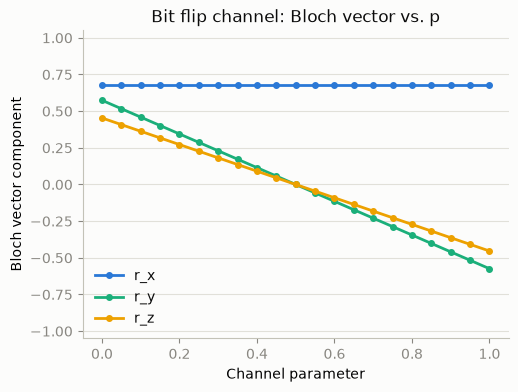

In [3]:

demo_circuit = single_qubit_superposition(theta=1.1, phi=0.7)
rho0 = DensityMatrix(Statevector.from_instruction(demo_circuit))
print("Initial Bloch vector:", np.round(bloch_vector(rho0), 4))

params = np.linspace(0, 1, 21)
bloch_vectors_bitflip = [bloch_vector(evolve_density_matrix(rho0, bit_flip_kraus(p))) for p in params]

plot_bloch_vector_decay(params, bloch_vectors_bitflip, title="Bit flip channel: Bloch vector vs. p")
plt.show()



**Reading the plot.** $r_x$ is flat (as predicted); $r_y$ and $r_z$ shrink linearly through zero
at $p=0.5$ and reappear with a flipped sign as $p \to 1$ — at $p=1$ the channel is the *deterministic*
unitary $X$, not noise at all, so the state is still pure, just rotated. Maximum decoherence
happens at $p=0.5$, where $y,z$ information is completely destroyed — makes sense, $p=0.5$ is
"coin-flip whether we apply $X$," maximally random.



## Phase flip channel

**Physical picture.** With probability $p$, a $Z$ error is applied. Unlike bit flip, this has
**no classical analogue**: in the computational ($Z$) basis, $Z$ does nothing to populations
($|0\rangle,|1\rangle$ are its eigenstates) — it only scrambles the *relative phase* between them,
i.e. destroys coherence without touching any classically-observable probability. A classical bit
has no notion of "phase" to scramble.

**Kraus operators.**

$$K_0 = \sqrt{1-p}\,I, \qquad K_1 = \sqrt{p}\,Z$$

**Effect on the Bloch vector.**

$$(r_x, r_y, r_z) \;\longrightarrow\; \big((1-2p)\,r_x,\ (1-2p)\,r_y,\ r_z\big)$$

The mirror image of bit flip: $z$ is preserved, $x,y$ shrink. This is the channel most directly
associated with **dephasing** — loss of quantum coherence with no energy exchange.


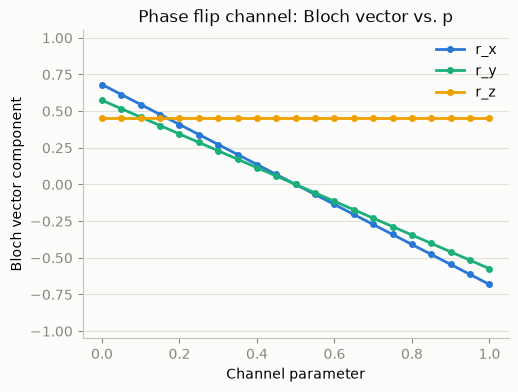

In [4]:

bloch_vectors_phaseflip = [bloch_vector(evolve_density_matrix(rho0, phase_flip_kraus(p))) for p in params]
plot_bloch_vector_decay(params, bloch_vectors_phaseflip, title="Phase flip channel: Bloch vector vs. p")
plt.show()



## Depolarizing channel

**Physical picture.** The "worst case" isotropic noise: it treats every direction on the Bloch
sphere identically, shrinking the whole state uniformly toward the center (maximally mixed). It's
the standard noise model used in **randomized benchmarking**, precisely because "isotropic" means
gate-orientation-independent — a single number (the depolarizing parameter) summarizes the error
rate regardless of which gate or basis you're in.

**Kraus operators** (Qiskit's own convention — the identity term is included in a uniform mixture
over all four single-qubit Paulis):

$$K_0=\sqrt{1-\tfrac{3p}{4}}\,I,\quad K_1=\sqrt{\tfrac{p}{4}}\,X,\quad
K_2=\sqrt{\tfrac{p}{4}}\,Y,\quad K_3=\sqrt{\tfrac{p}{4}}\,Z$$

Using $X\rho X+Y\rho Y+Z\rho Z = 2I-\rho$ (for normalized $\rho$), this channel simplifies to the
much more transparent closed form

$$\mathcal{E}(\rho) = (1-p)\,\rho + p\,\frac{I}{2}$$

— "with probability $p$, replace the state by the maximally mixed state." This is *why* $p$ here
means something slightly different from the $p$ in bit/phase flip (where $p$ is the probability of
one specific Pauli error): depolarizing's $p$ already has the identity contribution folded in, so
comparing depolarizing($p$) to bit-flip($p$) at the same $p$ is not an apples-to-apples error rate
— logged in `docs/interview_questions.md`.

**Effect on the Bloch vector — isotropic by construction:**

$$(r_x, r_y, r_z) \;\longrightarrow\; (1-p)\,(r_x, r_y, r_z)$$

All three components shrink by the *same* factor — the signature of "isotropic" noise, and the one
channel where the three Bloch-decay curves should sit exactly on top of each other.


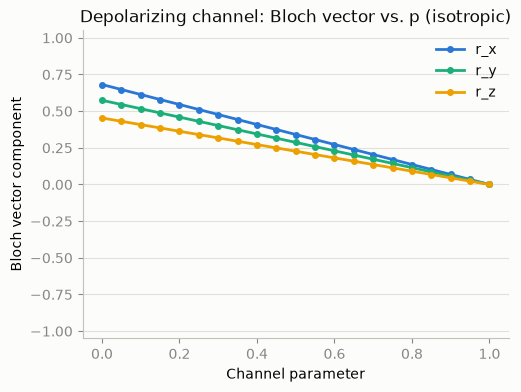

In [5]:

bloch_vectors_depol = [bloch_vector(evolve_density_matrix(rho0, depolarizing_kraus(p))) for p in params]
plot_bloch_vector_decay(params, bloch_vectors_depol, title="Depolarizing channel: Bloch vector vs. p (isotropic)")
plt.show()



## Amplitude damping channel

**Physical picture.** Models energy relaxation — a qubit encoded in excited/ground states
($|1\rangle$/$|0\rangle$) can spontaneously emit a photon and decay to $|0\rangle$, but the reverse
(spontaneous excitation) doesn't happen at zero temperature. This is the standard $T_1$-relaxation
channel: $\gamma$ is the probability of decay during the time window considered
($\gamma = 1-e^{-t/T_1}$ for idle time $t$).

**Kraus operators.**

$$K_0 = \begin{pmatrix}1 & 0\\0 & \sqrt{1-\gamma}\end{pmatrix}, \qquad
  K_1 = \begin{pmatrix}0 & \sqrt{\gamma}\\0 & 0\end{pmatrix}$$

$K_1$ literally implements "$|1\rangle \to |0\rangle$, with amplitude $\sqrt{\gamma}$" — a raising
operator's Hermitian conjugate acting as a jump operator.

**Effect on the Bloch vector — the key qualitative difference from every channel so far:**

$$(r_x, r_y, r_z) \;\longrightarrow\; \big(\sqrt{1-\gamma}\,r_x,\ \sqrt{1-\gamma}\,r_y,\ (1-\gamma)\,r_z + \gamma\big)$$

The $+\gamma$ term is new: this channel is **non-unital** — it does *not* map the maximally mixed
state to itself (check: $r=(0,0,0) \to (0,0,\gamma) \neq (0,0,0)$ for $\gamma>0$). Every other
channel in this notebook is **unital** (maps $I/2 \to I/2$; equivalently, all their Bloch-vector
maps are linear with no additive shift). Amplitude damping has a preferred fixed point,
$|0\rangle$ ($r_z=+1$), which every state is pulled toward as $\gamma\to 1$ — physically, "given
long enough, everything relaxes to the ground state," which is a *directional*, not merely
information-destroying, process.


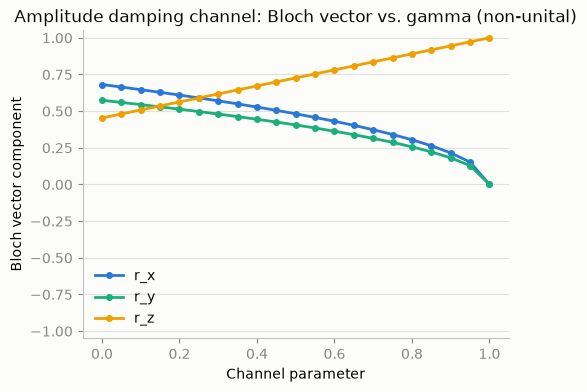

Bloch vector as gamma -> 1: [0. 0. 1.]  (pulled toward |0> = (0,0,1))


In [6]:

bloch_vectors_ampdamp = [bloch_vector(evolve_density_matrix(rho0, amplitude_damping_kraus(g))) for g in params]
plot_bloch_vector_decay(params, bloch_vectors_ampdamp, title="Amplitude damping channel: Bloch vector vs. gamma (non-unital)")
plt.show()

print("Bloch vector as gamma -> 1:", np.round(bloch_vectors_ampdamp[-1], 4), " (pulled toward |0> = (0,0,1))")



## Phase damping channel

**Physical picture.** Models pure dephasing — loss of phase coherence *without* any energy
exchange (no $T_1$ decay). This is the channel behind $T_2$ relaxation: $\lambda$ is the
probability of a "which-path" interaction with the environment revealing $|0\rangle$ vs
$|1\rangle$ without ever flipping the qubit.

**Kraus operators.**

$$K_0 = \begin{pmatrix}1 & 0\\0 & \sqrt{1-\lambda}\end{pmatrix}, \qquad
  K_1 = \begin{pmatrix}0 & 0\\0 & \sqrt{\lambda}\end{pmatrix}$$

**Effect on the Bloch vector.** $z$ is preserved exactly (populations untouched — literally the
definition of "no energy exchange"); $x,y$ shrink by $\sqrt{1-\lambda}$:

$$(r_x, r_y, r_z) \;\longrightarrow\; \big(\sqrt{1-\lambda}\,r_x,\ \sqrt{1-\lambda}\,r_y,\ r_z\big)$$

This has the *same shape* as phase flip's Bloch map (preserve $z$, shrink $x,y$) — and in fact it's
not just similar, it's **the same channel** under the reparametrization $p = \tfrac{1-\sqrt{1-\lambda}}{2}$,
which we can check directly via `SuperOp` equality (not just the Bloch-vector formula, which only
constrains 3 of the channel's real degrees of freedom):


phase_damping(lambda=0.55) == phase_flip(p=0.1646) ? True


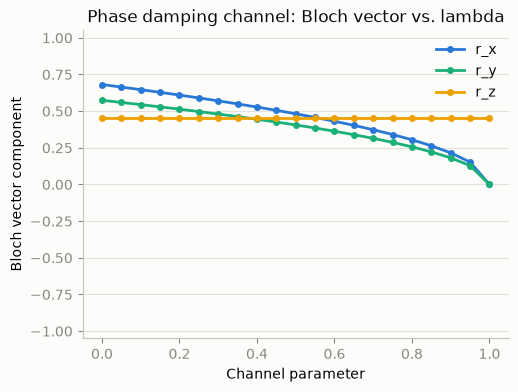

In [7]:

lam = 0.55
p_equiv = (1 - np.sqrt(1 - lam)) / 2

channel_a = SuperOp(Kraus(phase_damping_kraus(lam)))
channel_b = SuperOp(Kraus(phase_flip_kraus(p_equiv)))
print(f"phase_damping(lambda={lam}) == phase_flip(p={p_equiv:.4f}) ?", np.allclose(channel_a.data, channel_b.data))

bloch_vectors_phasedamp = [bloch_vector(evolve_density_matrix(rho0, phase_damping_kraus(l))) for l in params]
plot_bloch_vector_decay(params, bloch_vectors_phasedamp, title="Phase damping channel: Bloch vector vs. lambda")
plt.show()



So mathematically, phase damping and phase flip are the *same family of channels*, just
parametrized differently. The reason both names exist in practice: phase flip's $p$ is the natural
parameter for a discrete, one-shot Pauli-error model (e.g. a single noisy gate), while phase
damping's $\lambda = 1 - e^{-t/T_2}$ is the natural parameter for a *continuously acting* physical
process (idling for time $t$ next to a bath with a $T_2$ time). Same channel, different physical
story about where the parameter comes from — a genuinely good interview question, logged below.



## Comparing all five channels: purity vs. channel parameter

`Bloch vector decay` is the most granular view; a single scalar summary is the state's **purity**,
$\mathrm{Tr}(\rho^2)$, which is $1$ for a pure state and $\tfrac12$ for the maximally mixed
single-qubit state. Plotting purity against each channel's parameter, on the same axes, makes the
qualitative differences between channels comparable at a glance.


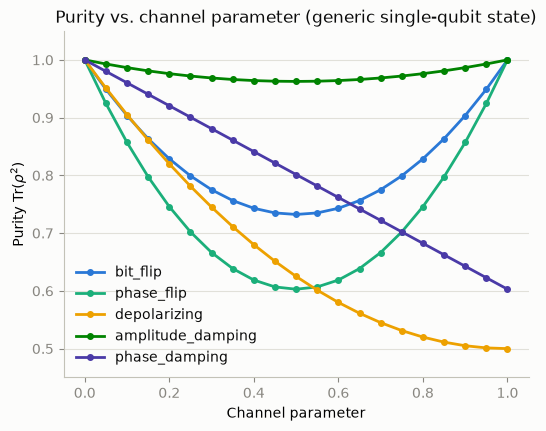

In [8]:

purities_by_channel = {}
for name, builder in CHANNEL_KRAUS_BUILDERS.items():
    param_name = "gamma" if name == "amplitude_damping" else ("lambda" if name == "phase_damping" else "p")
    purities_by_channel[name] = [purity(evolve_density_matrix(rho0, builder(x))).real for x in params]

plot_purity_vs_parameter(params, purities_by_channel, title="Purity vs. channel parameter (generic single-qubit state)")
plt.show()



**Reading the comparison.** Depolarizing is the fastest to destroy purity for a fixed parameter
value near the middle of the range (it attacks all three Bloch directions at once), while bit
flip/phase flip/phase damping only attack two of the three directions and so degrade purity more
slowly for a matched parameter. Amplitude damping is qualitatively different from all four others:
because it has a fixed point away from the center, purity at $\gamma=1$ returns to $1$ (the state
becomes the *pure* state $|0\rangle$) rather than continuing to degrade — the only channel here for
which "more noise" does not monotonically mean "less pure" in the limit.



## Verification against Qiskit's built-in noise channels

The Kraus operators above were derived by hand; before trusting them for anything (or shipping the
tests that verify this permanently), sanity-check each against `qiskit_aer.noise`'s own
implementations. As emphasized earlier, this must go through `SuperOp` (or `Choi`), not a
raw-operator comparison, since Kraus decompositions aren't unique.


In [9]:

checks = {
    "bit_flip (p=0.42)": (SuperOp(Kraus(bit_flip_kraus(0.42))),
                           SuperOp(Kraus(pauli_error([("X", 0.42), ("I", 0.58)])))),
    "phase_flip (p=0.42)": (SuperOp(Kraus(phase_flip_kraus(0.42))),
                             SuperOp(Kraus(pauli_error([("Z", 0.42), ("I", 0.58)])))),
    "depolarizing (p=0.42)": (SuperOp(Kraus(depolarizing_kraus(0.42))),
                               SuperOp(Kraus(depolarizing_error(0.42, 1)))),
    "amplitude_damping (gamma=0.42)": (SuperOp(Kraus(amplitude_damping_kraus(0.42))),
                                        SuperOp(Kraus(amplitude_damping_error(0.42)))),
    "phase_damping (lambda=0.42)": (SuperOp(Kraus(phase_damping_kraus(0.42))),
                                      SuperOp(Kraus(phase_damping_error(0.42)))),
}

for label, (ours, theirs) in checks.items():
    print(f"{label:32s} matches Qiskit built-in: {np.allclose(ours.data, theirs.data)}")


bit_flip (p=0.42)                matches Qiskit built-in: True
phase_flip (p=0.42)              matches Qiskit built-in: True
depolarizing (p=0.42)            matches Qiskit built-in: True
amplitude_damping (gamma=0.42)   matches Qiskit built-in: True
phase_damping (lambda=0.42)      matches Qiskit built-in: True



## Does this actually matter? Noisy Bell-state fidelity (a preview of Part 3)

One concrete demonstration: take the ideal Bell state from Part 1, apply depolarizing noise to
each qubit independently (a simplified stand-in for "each qubit picks up an error after the
entangling gate"), and track two things as the noise strength grows:

1. **Fidelity** to the ideal Bell state — computed exactly from the density matrix.
2. **Measured counts** at one fixed noise level — using the exact same `sample_counts(...,
   noise_model=...)` path exercised in `tests/test_noise_models.py`, to see the entangled-only
   `{"00","11"}` structure from Part 1 get contaminated with `"01"`/`"10"` outcomes.

This is deliberately a single illustrative slice, not the systematic sweep — Part 3 is where
fidelity/success-probability/error-rate get studied properly across noise probability, qubit
count, and circuit depth.


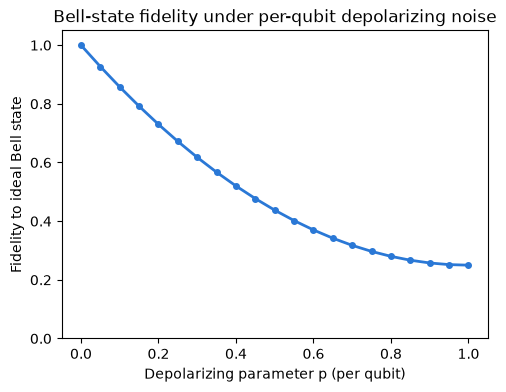

In [10]:

bell_rho_ideal = DensityMatrix(Statevector.from_instruction(bell_state("phi_plus")))

noise_params = np.linspace(0, 1, 21)
fidelities = []
for p in noise_params:
    noisy = bell_rho_ideal.evolve(Kraus(depolarizing_kraus(p)), qargs=[0])
    noisy = noisy.evolve(Kraus(depolarizing_kraus(p)), qargs=[1])
    fidelities.append(state_fidelity(bell_rho_ideal, noisy))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(noise_params, fidelities, color="#2a78d6", linewidth=2, marker="o", markersize=4)
ax.set_xlabel("Depolarizing parameter p (per qubit)")
ax.set_ylabel("Fidelity to ideal Bell state")
ax.set_title("Bell-state fidelity under per-qubit depolarizing noise")
ax.set_ylim(0, 1.05)
plt.show()


Noisy counts at p = 0.3 : {'11': 1542, '00': 1484, '10': 532, '01': 538}


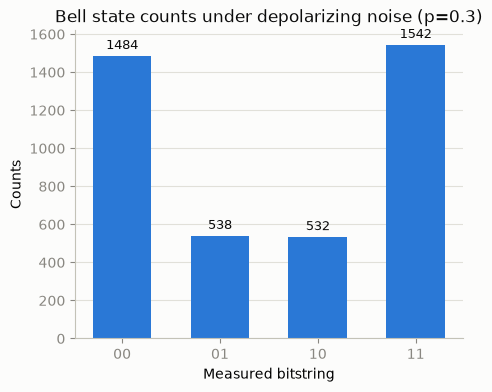

In [11]:

# One concrete noisy measurement at a fixed noise level, reusing the exact tested
# noise-injection mechanism (a noisy identity gate as a proxy for a post-entangling error).
p_fixed = 0.3
qc = bell_state("phi_plus")
qc.barrier()
qc.id(0)
qc.id(1)
qc.add_register(ClassicalRegister(2, name="meas"))
qc.measure([0, 1], [0, 1])

noise_model = single_qubit_noise_model(depolarizing_kraus(p_fixed), qubits=[0, 1], gate="id")
noisy_counts = sample_counts(qc, shots=4096, seed=42, noise_model=noise_model)
print("Noisy counts at p =", p_fixed, ":", noisy_counts)

plot_counts_histogram(noisy_counts, title=f"Bell state counts under depolarizing noise (p={p_fixed})")
plt.show()



Outcomes now appear outside $\{00, 11\}$ — exactly the signature Part 1 flagged as load-bearing
for the *ideal* Bell state (`set(counts) <= {"00", "11"}`). That assertion is a genuine noise
detector: it would fail the moment real noise enters the picture, which is exactly what we're
seeing here.



## Summary

- Physical noise is modeled by **Kraus operators**: $\rho \to \sum_i K_i \rho K_i^\dagger$, derived
  from "unitary evolution on system + environment, then trace out the environment" (Stinespring
  dilation) — the same `partial_trace` tool from Part 1, now tracing out an environment instead of
  an entanglement partner.
- Implemented five channels: **bit flip**, **phase flip**, **depolarizing**, **amplitude damping**,
  **phase damping** — each derived from a physical picture, verified against Qiskit's own
  `noise.errors` via `SuperOp` equality (never raw Kraus comparison — decompositions aren't unique).
- Visualized each via its effect on the Bloch vector of a generic single-qubit state, and
  summarized all five together via purity vs. parameter.
- Two channels are qualitatively different from the rest: depolarizing is **isotropic** (shrinks
  all three Bloch directions equally); amplitude damping is **non-unital** (has a preferred fixed
  point, $|0\rangle$, unlike every unital channel here).
- Phase damping and phase flip turned out to be the *same channel family* under reparametrization
  — a reminder that "channel identity" lives in the `SuperOp`/`Choi` representation, not in how a
  channel is conventionally parametrized or named.
- One demo showed noise degrading Bell-state fidelity and contaminating the previously
  noise-free `{00,11}` measurement structure — Part 3 will make this systematic.

Interview-style Q&A generated while building this notebook is logged in
`docs/interview_questions.md`, not repeated here.
